In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
import os

possible_paths = [
    'Genre Classification Dataset/train_data.txt',
    'train_data.txt',
    'train_data.csv',
    './Genre Classification Dataset/train_data.txt',
    '../Genre Classification Dataset/train_data.txt'
]

file_path = None
for path in possible_paths:
    if os.path.exists(path):
        file_path = path
        print(f"Found file at: {path}")
        break

if file_path is None:
    print("ERROR: Dataset file not found!")
    print("\nPlease check:")
    print("1. Have you downloaded the dataset from Kaggle?")
    print("2. Have you extracted the zip file?")
    print("3. Is train_data.txt in the correct folder?")
    print("\nCurrent working directory:", os.getcwd())
    print("\nFiles in current directory:")
    print(os.listdir('.'))
else:
    df = pd.read_csv(file_path, 
                     sep=':::', 
                     names=['Title', 'Genre', 'Description'], 
                     engine='python')
    
    print("Dataset loaded successfully!")
    print("Total Movies:", len(df))
    print("Total Genres:", df['Genre'].nunique())
    print("\nFirst 10 movies:")
    print(df.head(10))

Found file at: train_data.txt
Dataset loaded successfully!
Total Movies: 54214
Total Genres: 27

First 10 movies:
                                 Title          Genre  \
1        Oscar et la dame rose (2009)          drama    
2                        Cupid (1997)       thriller    
3    Young, Wild and Wonderful (1980)          adult    
4               The Secret Sin (1915)          drama    
5              The Unrecovered (2007)          drama    
6              Quality Control (2011)    documentary    
7                  "Pink Slip" (2009)         comedy    
8                One Step Away (1985)          crime    
9            "Desperate Hours" (2016)     reality-tv    
10                   Spirits (2014/I)         horror    

                                          Description  
1    Listening in to a conversation between his do...  
2    A brother and sister with a past incestuous r...  
3    As the bus empties the students for their fie...  
4    To help their unemployed fath

In [6]:
all_genres = sorted(df['Genre'].unique())
print("Total Genres:", len(all_genres))
print("\nComplete Genre List:")
for i, genre in enumerate(all_genres, 1):
    print(f"{i}. {genre}")

Total Genres: 27

Complete Genre List:
1.  action 
2.  adult 
3.  adventure 
4.  animation 
5.  biography 
6.  comedy 
7.  crime 
8.  documentary 
9.  drama 
10.  family 
11.  fantasy 
12.  game-show 
13.  history 
14.  horror 
15.  music 
16.  musical 
17.  mystery 
18.  news 
19.  reality-tv 
20.  romance 
21.  sci-fi 
22.  short 
23.  sport 
24.  talk-show 
25.  thriller 
26.  war 
27.  western 


Genre Distribution:
Genre
drama           13613
documentary     13096
comedy           7447
short            5073
horror           2204
thriller         1591
action           1315
western          1032
reality-tv        884
family            784
adventure         775
music             731
romance           672
sci-fi            647
adult             590
crime             505
animation         498
sport             432
talk-show         391
fantasy           323
mystery           319
musical           277
biography         265
history           243
game-show         194
news              181
war               132
Name: count, dtype: int64


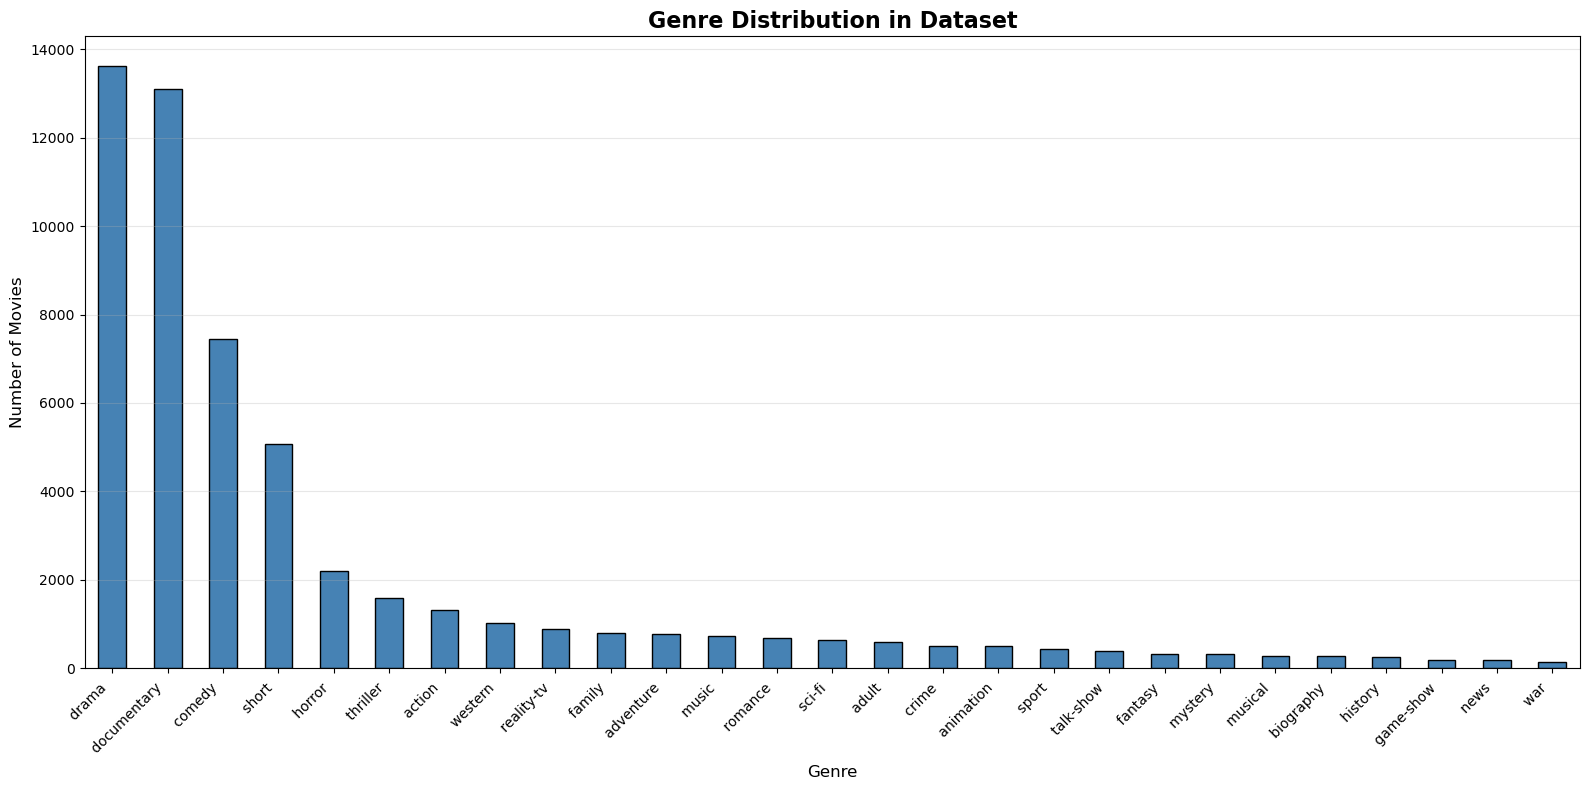

In [7]:
genre_counts = df['Genre'].value_counts()
print("Genre Distribution:")
print(genre_counts)

plt.figure(figsize=(16, 8))
genre_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Genre Distribution in Dataset', fontsize=16, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
print("Missing values:")
print(df.isnull().sum())

df = df.dropna()
print("\nDataset after cleaning:", df.shape)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = ' '.join(text.split())
    return text

df['Description_Clean'] = df['Description'].apply(clean_text)

print("\nText cleaning example:")
print("Original:", df['Description'].iloc[0][:150])
print("\nCleaned:", df['Description_Clean'].iloc[0][:150])

Missing values:
Title          0
Genre          0
Description    0
dtype: int64

Dataset after cleaning: (54214, 3)

Text cleaning example:
Original:  Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody has the courage to tell him. He only has a few we

Cleaned: listening in to a conversation between his doctor and parents yearold oscar learns what nobody has the courage to tell him he only has a few weeks to 


In [9]:
label_encoder = LabelEncoder()
df['Genre_Encoded'] = label_encoder.fit_transform(df['Genre'])

print("Genre Encoding Mapping:")
for i, genre in enumerate(label_encoder.classes_):
    print(f"{i}: {genre}")

Genre Encoding Mapping:
0:  action 
1:  adult 
2:  adventure 
3:  animation 
4:  biography 
5:  comedy 
6:  crime 
7:  documentary 
8:  drama 
9:  family 
10:  fantasy 
11:  game-show 
12:  history 
13:  horror 
14:  music 
15:  musical 
16:  mystery 
17:  news 
18:  reality-tv 
19:  romance 
20:  sci-fi 
21:  short 
22:  sport 
23:  talk-show 
24:  thriller 
25:  war 
26:  western 


In [10]:
X = df['Description_Clean']
y = df['Genre_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

test_indices = X_test.index

Training samples: 43371
Testing samples: 10843


In [14]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words='english'
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF Vectorization Complete!")
print("Matrix Shape:", X_train_tfidf.shape)
print("Number of Features:", len(tfidf_vectorizer.get_feature_names_out()))

TF-IDF Vectorization Complete!
Matrix Shape: (43371, 5000)
Number of Features: 5000


In [15]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine': LinearSVC(max_iter=1000, random_state=42)
}

results = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    accuracy = accuracy_score(y_test, y_pred)
    
    results[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'predictions': y_pred
    }
    
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, 
                                target_names=label_encoder.classes_,
                                zero_division=0))


Training Naive Bayes...
Accuracy: 0.5242 (52.42%)

Classification Report:
               precision    recall  f1-score   support

      action        0.61      0.10      0.18       263
       adult        0.69      0.09      0.16       118
   adventure        0.67      0.05      0.10       155
   animation        0.00      0.00      0.00       100
   biography        0.00      0.00      0.00        53
      comedy        0.50      0.43      0.46      1490
       crime        0.00      0.00      0.00       101
 documentary        0.57      0.89      0.70      2619
       drama        0.46      0.82      0.59      2723
      family        0.00      0.00      0.00       157
     fantasy        0.00      0.00      0.00        65
   game-show        1.00      0.21      0.34        39
     history        0.00      0.00      0.00        49
      horror        0.76      0.36      0.49       441
       music        0.73      0.11      0.19       146
     musical        0.00      0.00      0.00

In [16]:
print("Model Comparison:")
for model_name, result in results.items():
    print(f"{model_name}: {result['accuracy']:.4f} ({result['accuracy']*100:.2f}%)")

best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = results[best_model_name]['model']
best_accuracy = results[best_model_name]['accuracy']

print(f"\nBest Model: {best_model_name}")
print(f"Best Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

Model Comparison:
Naive Bayes: 0.5242 (52.42%)
Logistic Regression: 0.5776 (57.76%)
Support Vector Machine: 0.5657 (56.57%)

Best Model: Logistic Regression
Best Accuracy: 0.5776 (57.76%)


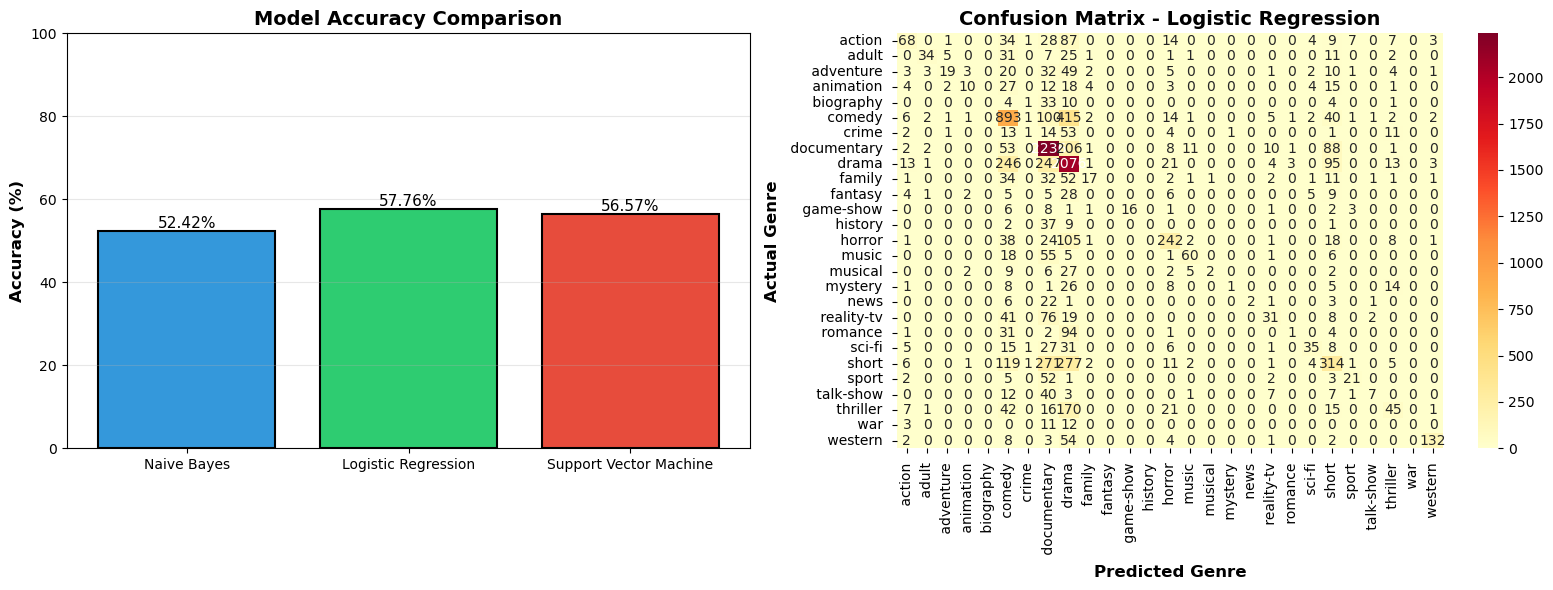

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = list(results.keys())
accuracies = [results[m]['accuracy']*100 for m in model_names]
colors = ['#3498db', '#2ecc71', '#e74c3c']

bars = axes[0].bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 100])
axes[0].grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=11)

cm = confusion_matrix(y_test, results[best_model_name]['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1],
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
axes[1].set_ylabel('Actual Genre', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Genre', fontsize=12, fontweight='bold')
axes[1].set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [18]:
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("Models saved successfully!")
print("Files created:")
print("  - best_model.pkl")
print("  - tfidf_vectorizer.pkl")
print("  - label_encoder.pkl")

Models saved successfully!
Files created:
  - best_model.pkl
  - tfidf_vectorizer.pkl
  - label_encoder.pkl


In [19]:
def predict_genre_all_probabilities(movie_description, movie_title="Unknown"):
    cleaned = clean_text(movie_description)
    tfidf = tfidf_vectorizer.transform([cleaned])
    prediction = best_model.predict(tfidf)
    predicted_genre = label_encoder.inverse_transform(prediction)[0]
    
    print("\n" + "="*80)
    print("MOVIE GENRE PREDICTION - COMPLETE ANALYSIS")
    print("="*80)
    print(f"\nMovie Title: {movie_title}")
    print(f"\nDescription: {movie_description[:200]}...")
    print(f"\nPREDICTED GENRE: {predicted_genre.upper()}")
    print(f"Model Used: {best_model_name}")
    
    if hasattr(best_model, 'predict_proba'):
        probs = best_model.predict_proba(tfidf)[0]
        
        print(f"\n{'='*80}")
        print(f"ALL GENRE PROBABILITIES ({len(label_encoder.classes_)} GENRES)")
        print("="*80)
        
        prob_df = pd.DataFrame({
            'Rank': range(1, len(label_encoder.classes_) + 1),
            'Genre': label_encoder.classes_,
            'Probability (%)': probs * 100
        })
        
        prob_df = prob_df.sort_values('Probability (%)', ascending=False).reset_index(drop=True)
        prob_df['Rank'] = range(1, len(prob_df) + 1)
        
        for idx, row in prob_df.iterrows():
            bar = '#' * int(row['Probability (%)'] / 2)
            print(f"{row['Rank']:2d}. {row['Genre']:<20} {row['Probability (%)']:>6.2f}% {bar}")
        
        print(f"\n{'='*80}")
        print("TOP 10 GENRES:")
        print(prob_df[['Rank', 'Genre', 'Probability (%)']].head(10))
        
        plt.figure(figsize=(12, 6))
        top10 = prob_df.head(10)
        plt.barh(top10['Genre'], top10['Probability (%)'], 
                color='skyblue', edgecolor='black')
        plt.xlabel('Probability (%)', fontsize=12, fontweight='bold')
        plt.ylabel('Genre', fontsize=12, fontweight='bold')
        plt.title(f'Top 10 Genre Probabilities: {movie_title}', 
                 fontsize=14, fontweight='bold')
        plt.xlim([0, 100])
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("\nNote: This model does not provide probability estimates")
    
    print("="*80)
    return predicted_genre

print("Prediction function created successfully!")

Prediction function created successfully!


In [20]:
np.random.seed(42)
sample_indices = np.random.choice(test_indices, size=10, replace=False)
sample_movies = df.loc[sample_indices].copy()

print(f"Selected {len(sample_movies)} random movies from test dataset")
print("\nSample Movies:")
print(sample_movies[['Title', 'Genre']].head(10))

Selected 10 random movies from test dataset

Sample Movies:
                                                  Title          Genre
20516                  Greed: Heavy Is The Hand (2018)         action 
27038                      Penguins Under Siege (2004)    documentary 
24649                          Talk Nerdy to Me (2016)         comedy 
2408    Jim Morrison: An American Poet in Paris (2006)    documentary 
32797                                   Skyfire (1920)          drama 
14758                                Camp Death (2006)          short 
46356                      "Hvor er vi landet?" (2008)      game-show 
44738                                Two Fisted (1935)         comedy 
9086                            The Hidden Code (1920)      adventure 
27162                               Iddiuluaata (2017)          short 



################################################################################
MOVIE 1 OF 10
################################################################################

MOVIE GENRE PREDICTION - COMPLETE ANALYSIS

Movie Title:  Greed: Heavy Is The Hand (2018) 

Description:  A team of professional hitmen take on a job that gets them caught between political agendas, cops, and a dangerous arms dealer. Alex and Reaper lead a team of highly trained hitmen who have seemingly...

PREDICTED GENRE:  ACTION 
Model Used: Logistic Regression

ALL GENRE PROBABILITIES (27 GENRES)
 1.  action               61.98% ##############################
 2.  drama                 7.15% ###
 3.  reality-tv            7.07% ###
 4.  documentary           6.01% ###
 5.  thriller              3.60% #
 6.  comedy                3.48% #
 7.  sport                 1.93% 
 8.  sci-fi                1.77% 
 9.  crime                 1.10% 
10.  horror                1.08% 
11.  animation             0.50% 
12

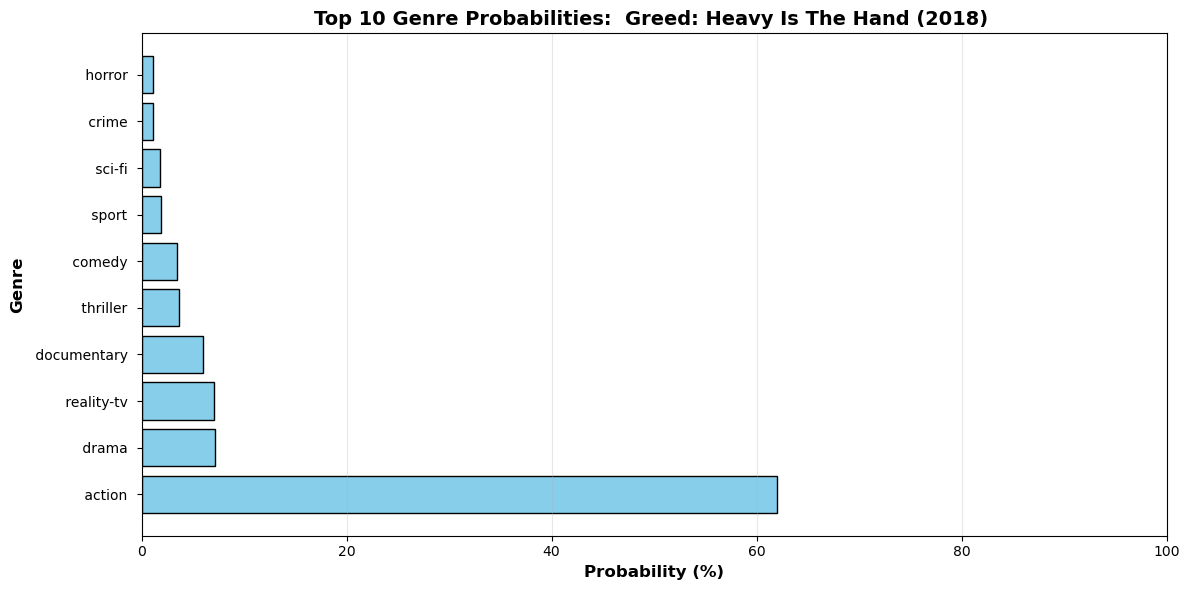


################################################################################
MOVIE 2 OF 10
################################################################################

MOVIE GENRE PREDICTION - COMPLETE ANALYSIS

Movie Title:  Penguins Under Siege (2004) 

Description:  Lucy and Louie are vulnerable penguin chicks born in the harsh environment of The Skeleton coast of Southwestern Africa, commonly known as the Coast of Fury.From rogue sea lions that lurk offshore to...

PREDICTED GENRE:  DOCUMENTARY 
Model Used: Logistic Regression

ALL GENRE PROBABILITIES (27 GENRES)
 1.  documentary          59.63% #############################
 2.  drama                 8.72% ####
 3.  short                 7.56% ###
 4.  comedy                6.15% ###
 5.  adventure             3.51% #
 6.  action                1.41% 
 7.  horror                1.24% 
 8.  thriller              1.23% 
 9.  animation             1.16% 
10.  reality-tv            1.12% 
11.  family                0.80% 
12

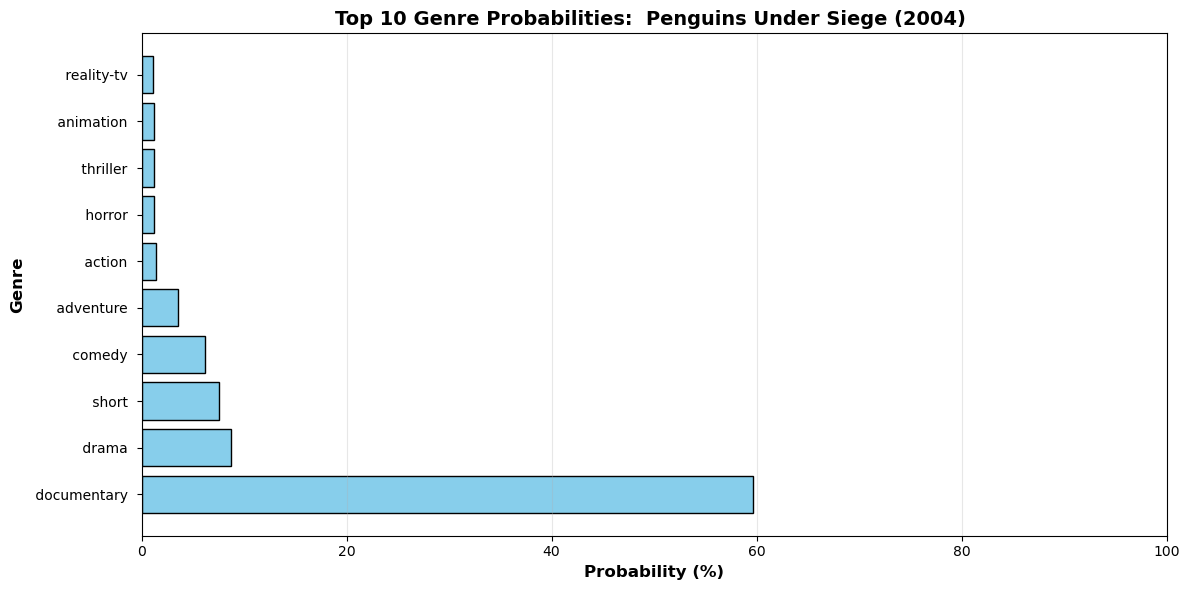


################################################################################
MOVIE 3 OF 10
################################################################################

MOVIE GENRE PREDICTION - COMPLETE ANALYSIS

Movie Title:  Talk Nerdy to Me (2016) 

Description:  Talk Nerdy to Me is a comedy about Michelle Moore an All-American cheerleader and the most popular girl at Wellington High School. The type of girl who wouldn't look twice at a nerd like Derek Lector...

PREDICTED GENRE:  COMEDY 
Model Used: Logistic Regression

ALL GENRE PROBABILITIES (27 GENRES)
 1.  comedy               62.46% ###############################
 2.  drama                21.11% ##########
 3.  short                 4.30% ##
 4.  documentary           2.80% #
 5.  horror                1.53% 
 6.  romance               1.28% 
 7.  talk-show             0.78% 
 8.  family                0.72% 
 9.  thriller              0.59% 
10.  adult                 0.55% 
11.  animation             0.50% 
12.  ac

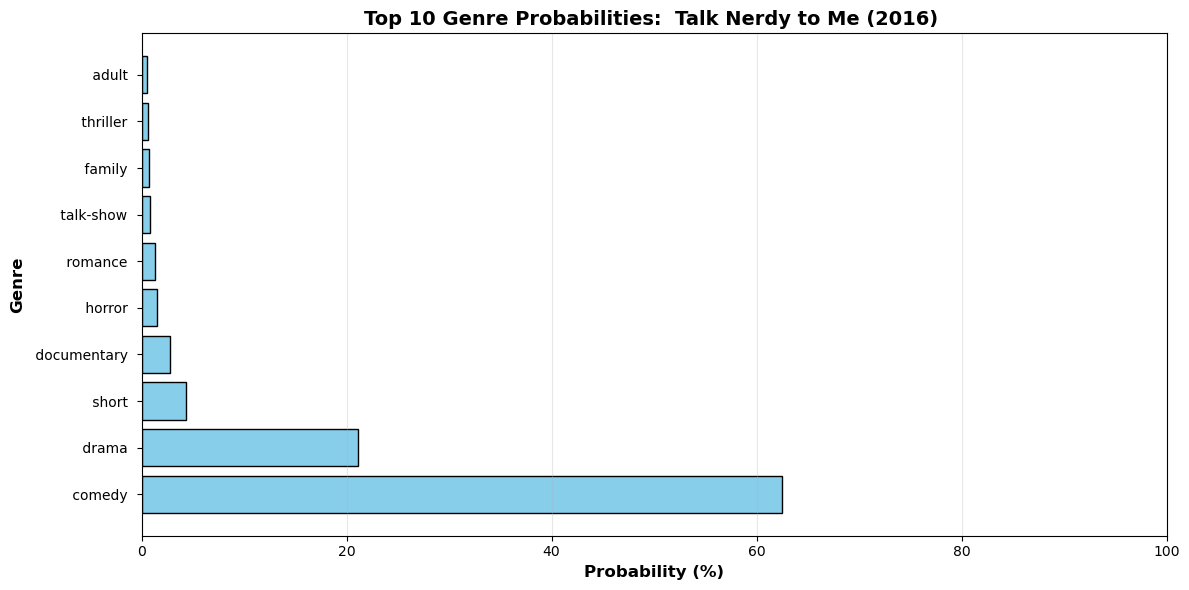


################################################################################
MOVIE 4 OF 10
################################################################################

MOVIE GENRE PREDICTION - COMPLETE ANALYSIS

Movie Title:  Jim Morrison: An American Poet in Paris (2006) 

Description:  This documentary retraces the last four months in the life of rock legend Jim Morrison and searches for the causes that led up to his mysterious death in Paris on July 3, 1971. Interviews with expert...

PREDICTED GENRE:  DOCUMENTARY 
Model Used: Logistic Regression

ALL GENRE PROBABILITIES (27 GENRES)
 1.  documentary          93.02% ##############################################
 2.  short                 0.89% 
 3.  biography             0.62% 
 4.  horror                0.61% 
 5.  action                0.45% 
 6.  mystery               0.41% 
 7.  music                 0.38% 
 8.  comedy                0.35% 
 9.  adventure             0.34% 
10.  thriller              0.31% 
11.  sci-fi

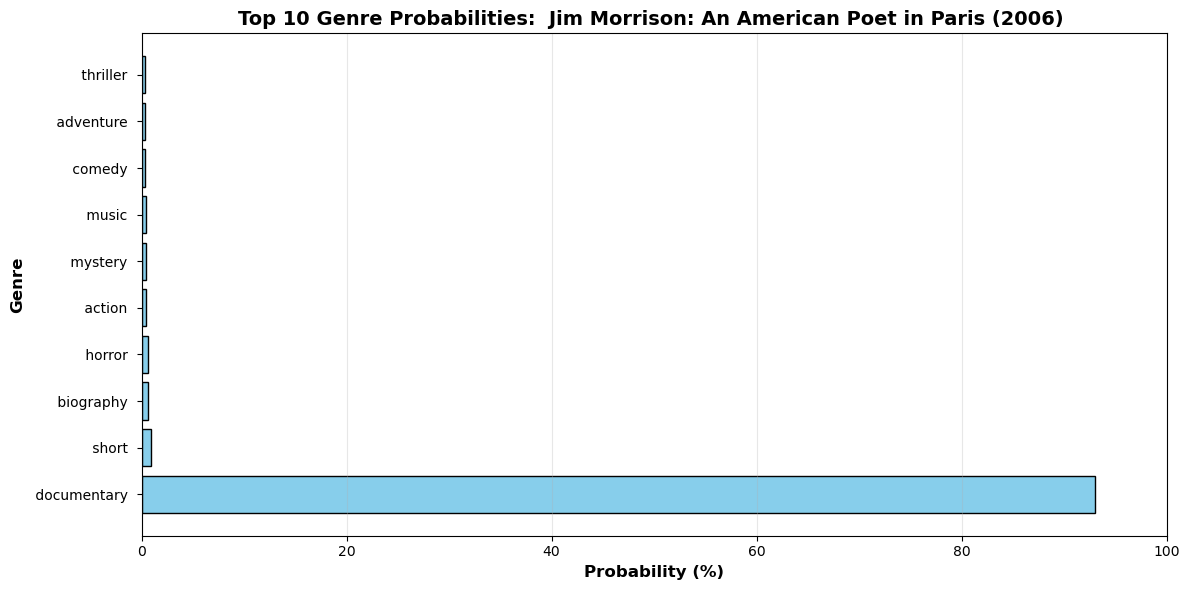


################################################################################
MOVIE 5 OF 10
################################################################################

MOVIE GENRE PREDICTION - COMPLETE ANALYSIS

Movie Title:  Skyfire (1920) 

Description:  Canadian Mountie Barr Conroy ( Neal Hart ) heads to the lawless trading post Skyfire in search of the killer of one of his comrades. There he is pursued by a man who believes that Conroy has insulted...

PREDICTED GENRE:  DRAMA 
Model Used: Logistic Regression

ALL GENRE PROBABILITIES (27 GENRES)
 1.  drama                37.01% ##################
 2.  comedy               17.33% ########
 3.  western              10.01% #####
 4.  short                 8.63% ####
 5.  thriller              6.91% ###
 6.  horror                4.08% ##
 7.  action                2.68% #
 8.  crime                 2.07% #
 9.  documentary           1.77% 
10.  mystery               1.39% 
11.  adventure             1.38% 
12.  romance       

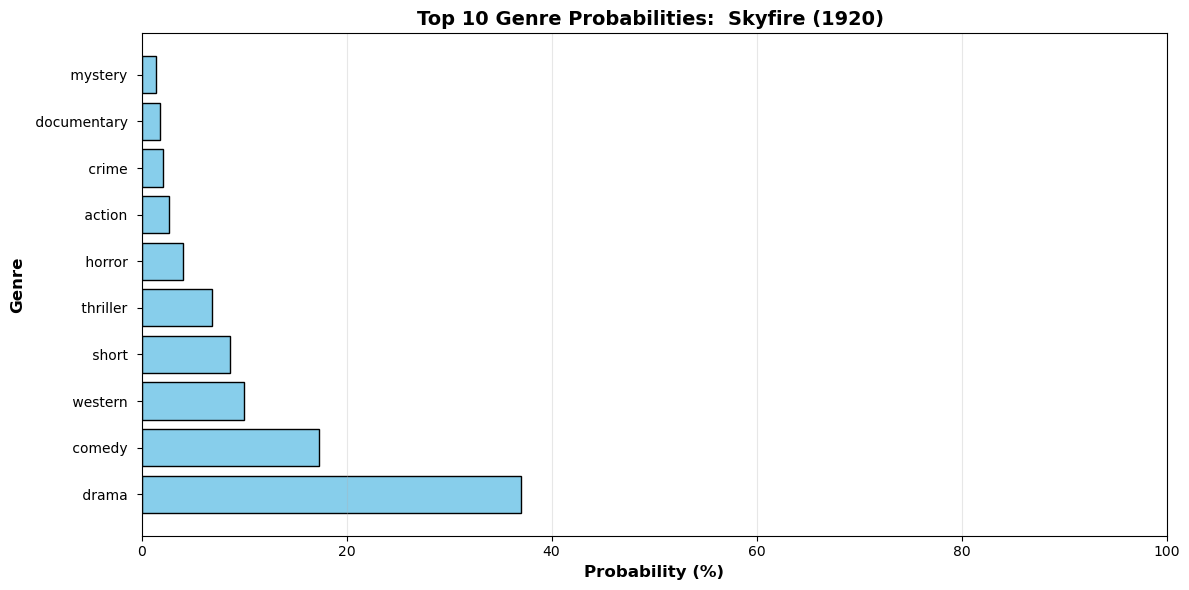


################################################################################
MOVIE 6 OF 10
################################################################################

MOVIE GENRE PREDICTION - COMPLETE ANALYSIS

Movie Title:  Camp Death (2006) 

Description:  Tensions is high at a long deserted summer camp where an independent slasher movie is being filmed. With the clock counting down and very little time for re-shoots the cast and crew are at each other...

PREDICTED GENRE:  HORROR 
Model Used: Logistic Regression

ALL GENRE PROBABILITIES (27 GENRES)
 1.  horror               56.52% ############################
 2.  documentary          10.53% #####
 3.  short                 8.24% ####
 4.  comedy                3.83% #
 5.  drama                 3.26% #
 6.  family                2.54% #
 7.  thriller              2.26% #
 8.  action                1.86% 
 9.  reality-tv            1.39% 
10.  adult                 1.07% 
11.  adventure             1.02% 
12.  animation  

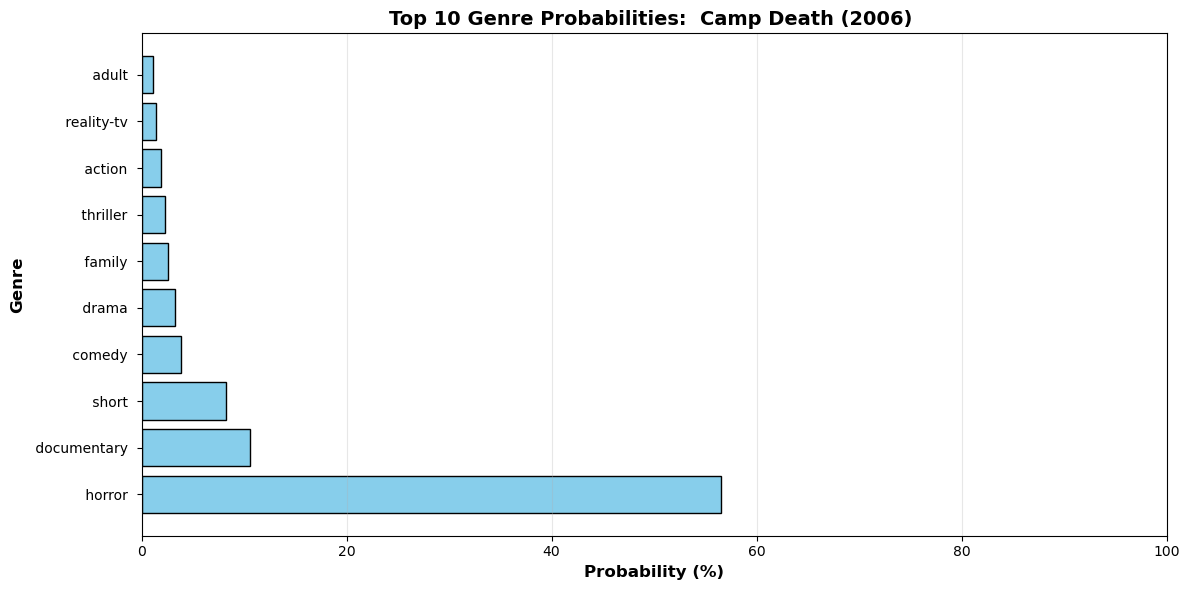


################################################################################
MOVIE 7 OF 10
################################################################################

MOVIE GENRE PREDICTION - COMPLETE ANALYSIS

Movie Title:  "Hvor er vi landet?" (2008) 

Description:  Two lifestyle experts are flown to a foreign country and taken to a home without being allowed to know where they are. By looking at the home and its contents they have to guess which country they ar...

PREDICTED GENRE:  DOCUMENTARY 
Model Used: Logistic Regression

ALL GENRE PROBABILITIES (27 GENRES)
 1.  documentary          35.87% #################
 2.  reality-tv           21.22% ##########
 3.  drama                14.97% #######
 4.  comedy                5.97% ##
 5.  family                4.38% ##
 6.  short                 4.11% ##
 7.  action                1.95% 
 8.  romance               1.56% 
 9.  adventure             1.22% 
10.  music                 1.13% 
11.  horror                0.94% 
12

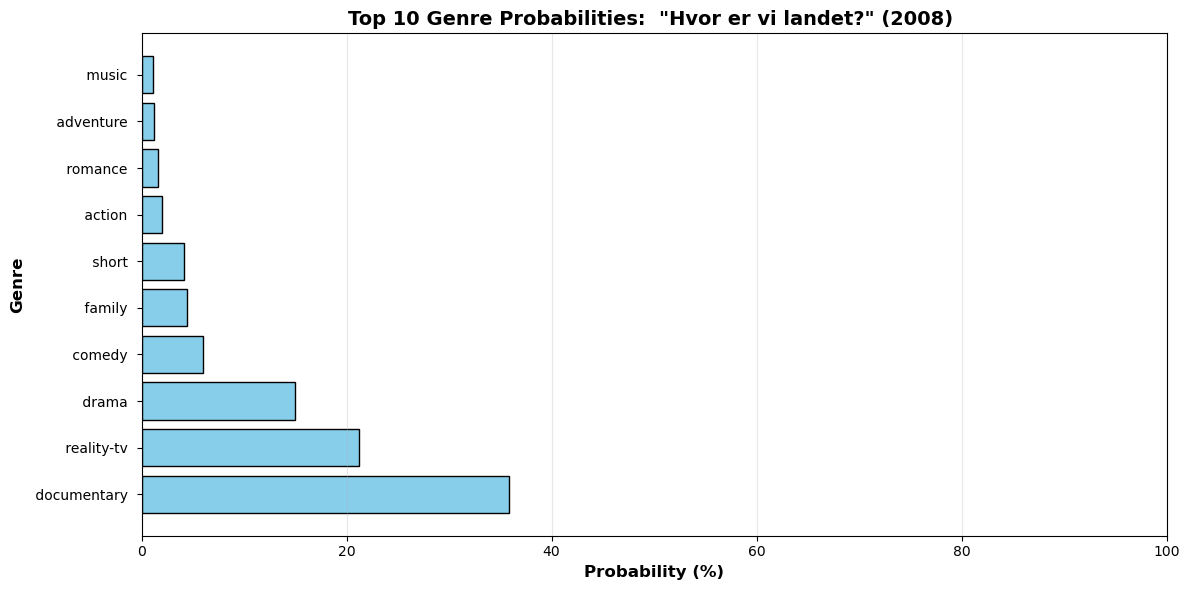


################################################################################
MOVIE 8 OF 10
################################################################################

MOVIE GENRE PREDICTION - COMPLETE ANALYSIS

Movie Title:  Two Fisted (1935) 

Description:  A fast-talking boxing manager and the somewhat hapless fighter he manages happen to run into a young man who was a good prizefighter in his day but is now out of the sport and has a drinking problem....

PREDICTED GENRE:  COMEDY 
Model Used: Logistic Regression

ALL GENRE PROBABILITIES (27 GENRES)
 1.  comedy               52.02% ##########################
 2.  drama                18.42% #########
 3.  short                 6.69% ###
 4.  action                5.99% ##
 5.  documentary           2.87% #
 6.  sport                 1.69% 
 7.  thriller              1.51% 
 8.  crime                 1.34% 
 9.  adventure             0.93% 
10.  romance               0.90% 
11.  reality-tv            0.80% 
12.  western    

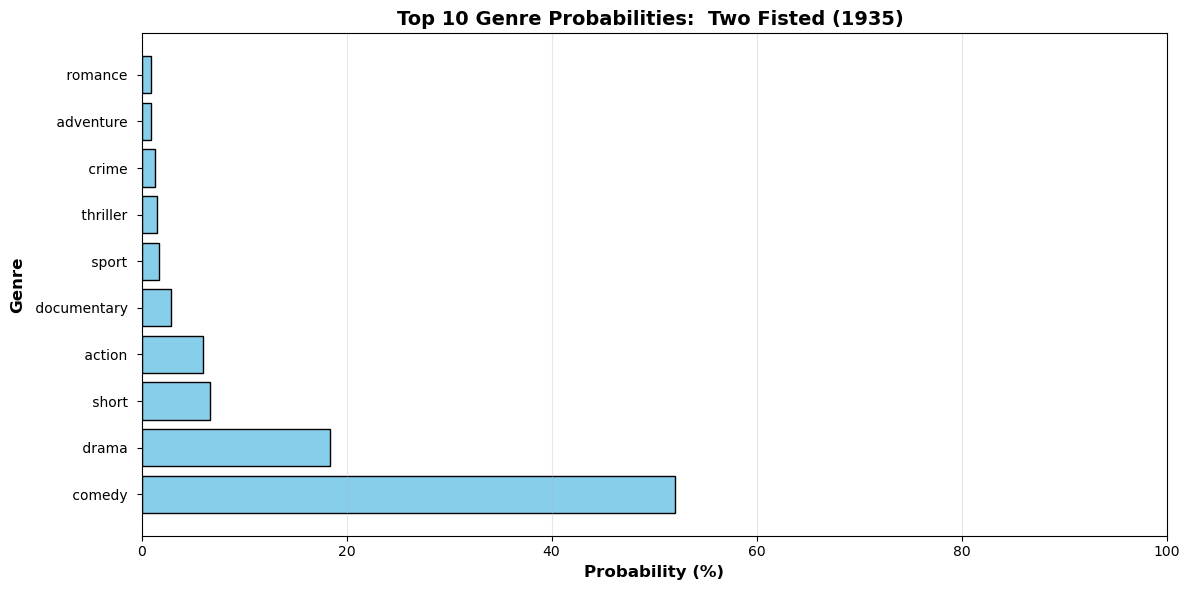


################################################################################
MOVIE 9 OF 10
################################################################################

MOVIE GENRE PREDICTION - COMPLETE ANALYSIS

Movie Title:  The Hidden Code (1920) 

Description:  Quirky chemist Eben Lamont has discovered a powerful new explosive and plans to turn it over to the government. Richard Leslie, the head of an explosives manufacturing company, offers to buy his new ...

PREDICTED GENRE:  COMEDY 
Model Used: Logistic Regression

ALL GENRE PROBABILITIES (27 GENRES)
 1.  comedy               31.16% ###############
 2.  thriller             16.41% ########
 3.  drama                10.31% #####
 4.  sci-fi                5.44% ##
 5.  action                5.05% ##
 6.  adventure             4.51% ##
 7.  documentary           3.82% #
 8.  short                 3.61% #
 9.  western               3.60% #
10.  horror                2.85% #
11.  adult                 1.94% 
12.  crime    

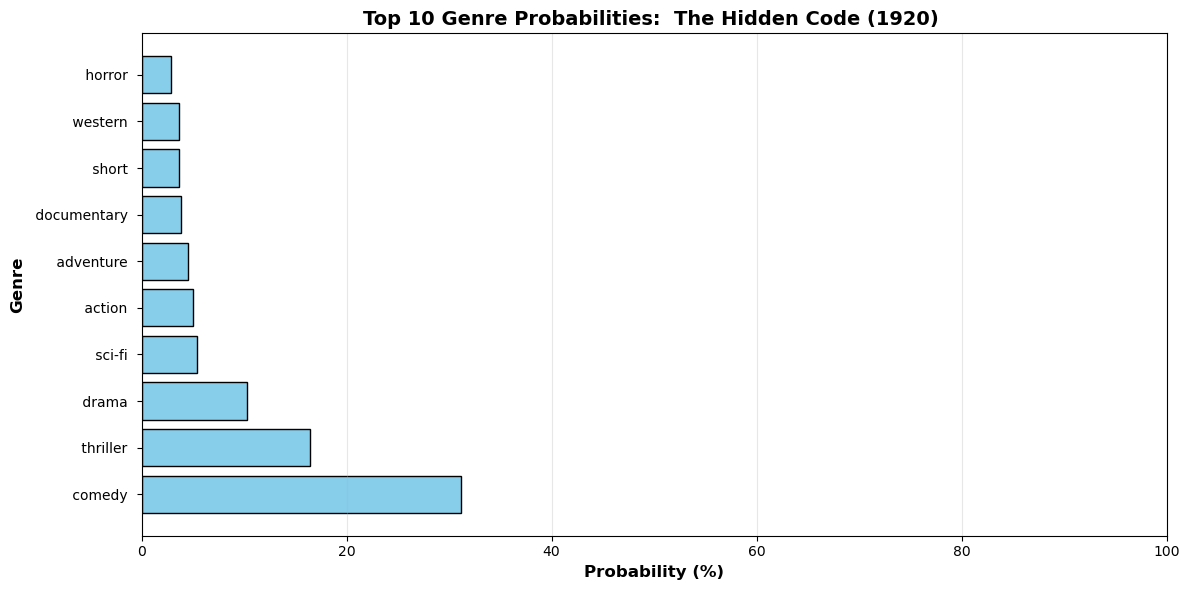


################################################################################
MOVIE 10 OF 10
################################################################################

MOVIE GENRE PREDICTION - COMPLETE ANALYSIS

Movie Title:  Iddiuluaata (2017) 

Description:  A butcher visits Janaki, who is left with no option other than prostitution after her husband left her and her daughter. Living in a slum with no education, she is barely able to meet ends. The butch...

PREDICTED GENRE:  DRAMA 
Model Used: Logistic Regression

ALL GENRE PROBABILITIES (27 GENRES)
 1.  drama                49.08% ########################
 2.  short                16.49% ########
 3.  comedy               14.96% #######
 4.  documentary           3.79% #
 5.  thriller              2.59% #
 6.  horror                1.65% 
 7.  romance               1.49% 
 8.  adventure             1.11% 
 9.  family                0.99% 
10.  crime                 0.97% 
11.  action                0.97% 
12.  western   

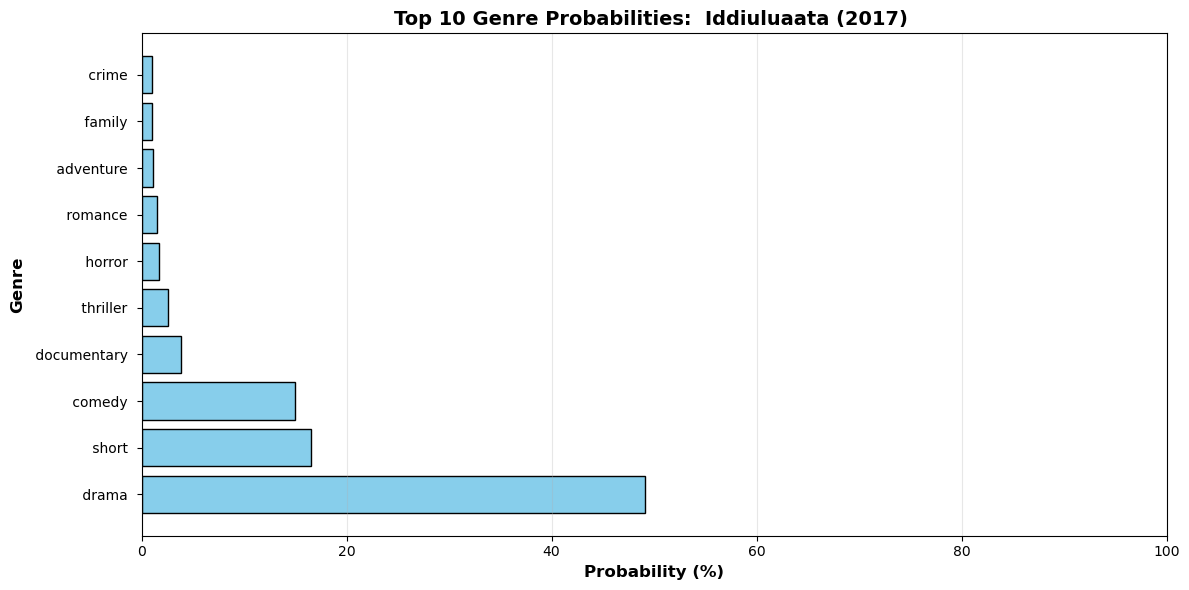


All predictions completed!


In [21]:
predictions_list = []

for idx, row in sample_movies.iterrows():
    print(f"\n{'#'*80}")
    print(f"MOVIE {len(predictions_list) + 1} OF {len(sample_movies)}")
    print("#"*80)
    
    pred_genre = predict_genre_all_probabilities(row['Description'], row['Title'])
    
    predictions_list.append({
        'S.No': len(predictions_list) + 1,
        'Movie Name': row['Title'],
        'Actual Genre': row['Genre'],
        'Predicted Genre': pred_genre,
        'Match': 'YES' if row['Genre'].lower() == pred_genre.lower() else 'NO'
    })

print("\nAll predictions completed!")

In [22]:
results_df = pd.DataFrame(predictions_list)

print("\n" + "="*80)
print("FINAL PREDICTION RESULTS TABLE")
print("="*80)
print(results_df)

correct = sum(results_df['Match'] == 'YES')
accuracy_pct = (correct / len(results_df)) * 100

print(f"\n{'='*80}")
print(f"ACCURACY ON SAMPLE MOVIES: {correct}/{len(results_df)} ({accuracy_pct:.2f}%)")
print("="*80)


FINAL PREDICTION RESULTS TABLE
   S.No                                        Movie Name   Actual Genre  \
0     1                  Greed: Heavy Is The Hand (2018)         action    
1     2                      Penguins Under Siege (2004)    documentary    
2     3                          Talk Nerdy to Me (2016)         comedy    
3     4   Jim Morrison: An American Poet in Paris (2006)    documentary    
4     5                                   Skyfire (1920)          drama    
5     6                                Camp Death (2006)          short    
6     7                      "Hvor er vi landet?" (2008)      game-show    
7     8                                Two Fisted (1935)         comedy    
8     9                           The Hidden Code (1920)      adventure    
9    10                               Iddiuluaata (2017)          short    

  Predicted Genre Match  
0         action    YES  
1    documentary    YES  
2         comedy    YES  
3    documentary    YES  
4

In [23]:
print("\n" + "="*80)
print("FINAL MODEL SUMMARY")
print("="*80)

print(f"\nBest Model: {best_model_name}")
print(f"Model Accuracy: {best_accuracy*100:.2f}%")
print(f"Total Training Samples: {len(X_train)}")
print(f"Total Testing Samples: {len(X_test)}")
print(f"Total Genres: {len(label_encoder.classes_)}")

print(f"\n{'='*80}")
print(f"COMPLETE LIST OF ALL {len(label_encoder.classes_)} GENRES")
print("="*80)

genres_list = pd.DataFrame({
    'No.': range(1, len(label_encoder.classes_) + 1),
    'Genre': sorted(label_encoder.classes_),
    'Movies in Dataset': [len(df[df['Genre'] == g]) for g in sorted(label_encoder.classes_)]
})

print(genres_list)

print("\n" + "="*80)
print("ALL PROCESSING COMPLETE!")
print("="*80)
print("\nTo predict any movie genre, use:")
print("predict_genre_all_probabilities(df.loc[INDEX, 'Description'], df.loc[INDEX, 'Title'])")


FINAL MODEL SUMMARY

Best Model: Logistic Regression
Model Accuracy: 57.76%
Total Training Samples: 43371
Total Testing Samples: 10843
Total Genres: 27

COMPLETE LIST OF ALL 27 GENRES
    No.          Genre  Movies in Dataset
0     1        action                1315
1     2         adult                 590
2     3     adventure                 775
3     4     animation                 498
4     5     biography                 265
5     6        comedy                7447
6     7         crime                 505
7     8   documentary               13096
8     9         drama               13613
9    10        family                 784
10   11       fantasy                 323
11   12     game-show                 194
12   13       history                 243
13   14        horror                2204
14   15         music                 731
15   16       musical                 277
16   17       mystery                 319
17   18          news                 181
18   19    realit